# Agenda 

1. Image acquisition techniques.
2. Image formats and color spaces.
3. Image enhancement and filtering techniques.

## Image acquisition techniques
1. Read image
2. video 
3. live-stream

In [1]:
import cv2 as cv 
import matplotlib.pyplot as plt 
import numpy as np
import sys
%matplotlib inline

def show(img, title=None):
    """Display a BGR/grayscale OpenCV image inline with matplotlib (safe for unattended execution)."""
    if img is None:
        print(f"[{title}] no image to display")
        return
    display_img = cv.cvtColor(img, cv.COLOR_BGR2RGB) if img.ndim == 3 else img
    cmap = None if img.ndim == 3 else 'gray'
    plt.figure()
    plt.imshow(display_img, cmap=cmap)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()


### Read an image from file ([imread(path ,Colorflage)](https://docs.opencv.org/4.x/d4/da8/group__imgcodecs.html#ga288b8b3da0892bd651fce07b3bbd3a56))
- **path :**  location of image in files (For example : image\file\NameOfImage )
- **Colorflage :** to read BGR image value **(1)** and Gray image value **(0)**

<img src="../assets/reference_images/bgr_colorflag_example.png" alt="drawing" style="width:200px;"/>

In [2]:
path = './images/dogBGR.jpg'
image = cv.imread(path, -1)

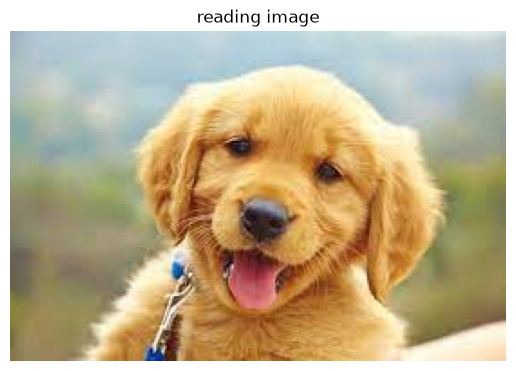

In [3]:
show(image, "reading image")

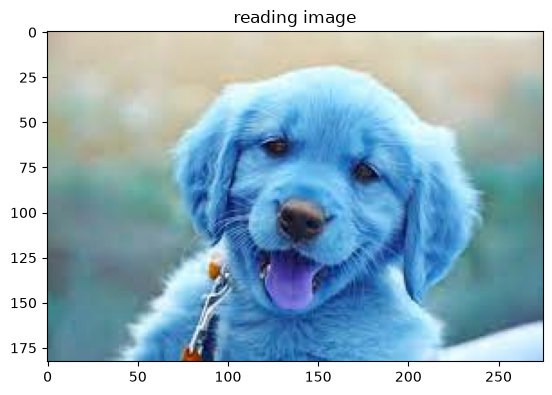

In [4]:
plt.imshow(image)
plt.title('reading image')
plt.show()

---
## Hint
1. Opencv works by colorspace BGR
2. matplotlib works by colorspace RGB

---

## Video Reading


### Read an video from folder ([VideoCapture(path)](https://docs.opencv.org/3.4/d8/dfe/classcv_1_1VideoCapture.html#a57c0e81e83e60f36c83027dc2a188e806))

In [5]:
!ls 

Filters_only.ipynb
Session2.ipynb
Session2_cont.ipynb
Videos
images


In [6]:
cap_video = cv.VideoCapture('./Videos/video1.mp4')

In [7]:
print(type(cap_video))

<class 'cv2.VideoCapture'>


In [8]:
print(cap_video.isOpened())

True


### False path

In [9]:
cap_video1 = cv.VideoCapture('wrong path')

In [10]:
print(type(cap_video1))

<class 'cv2.VideoCapture'>


In [11]:
print(cap_video1.isOpened())

False


### Helper Functions  ([get(typeofget)](https://docs.opencv.org/4.0.1/d8/dfe/classcv_1_1VideoCapture.html#aa6480e6972ef4c00d74814ec841a2939))

#### get the size (width and height)

In [12]:
# Frame Width
print(cap_video.get(cv.CAP_PROP_FRAME_WIDTH))

640.0


In [13]:
# Frame HEIGHT
print(cap_video.get(cv.CAP_PROP_FRAME_HEIGHT))

360.0


In [14]:
# FRAME FPS
print(cap_video.get(cv.CAP_PROP_FPS))

25.0


### Helper Functions  ([set(typeofget,Value)](https://docs.opencv.org/4.0.1/d8/dfe/classcv_1_1VideoCapture.html#a8c6d8c2d37505b5ca61ffd4bb54e9a7c9))
1. Return True if Changed and False if not 

In [15]:
# Set Frame WIDTH Size
print(cap_video.set(cv.CAP_PROP_FRAME_WIDTH,320))

False


In [16]:
# Set Frame Height size 
print(cap_video.set(cv.CAP_PROP_FRAME_HEIGHT,200))

False


### for read frame from video [read()](https://docs.opencv.org/4.0.1/d8/dfe/classcv_1_1VideoCapture.html#a473055e77dd7faa4d26d686226b292c1)

In [17]:
retvalue , frame = cap_video.read()

In [18]:
# True if ready frame correct and false if frame not ready or have problem 
print(retvalue)


True


In [19]:
print(type(frame))

<class 'numpy.ndarray'>


In [20]:
print(frame.shape)

(360, 640, 3)


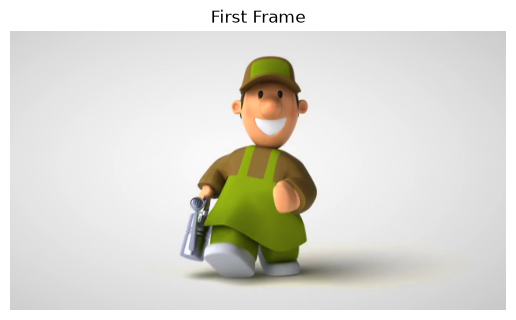

In [21]:
show(frame, "First Frame")

## Reading all frames 

Read 158 more frames from the video.


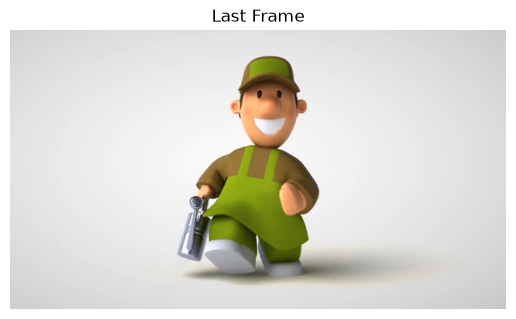

In [22]:
frame_count = 0
last_frame = None
while cap_video.isOpened():
    ret, frame = cap_video.read()
    if not ret:
        break
    frame_count += 1
    last_frame = frame

print(f"Read {frame_count} more frames from the video.")
show(last_frame, "Last Frame")

## Playback video

In [23]:
delay = 20
window_name = 'frame'

cap = cv.VideoCapture('./Videos/video1.mp4')

if not cap.isOpened():
    sys.exit()


while cap.isOpened():
    ret, frame = cap.read()
    if ret:
        cv.imshow(window_name, frame)
        if cv.waitKey(delay) & 0xFF == ord('q'):
            break
    else:
        break

cv.destroyWindow(window_name)

## Reading From Camera 

In [24]:
camera_id = 0
delay = 400
window_name = 'frame'

cap = cv.VideoCapture(camera_id)

if not cap.isOpened():
    print(f"No camera detected (camera_id={camera_id}) - skipping live capture demo.")
else:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        cv.imshow(window_name, frame)
        if cv.waitKey(delay) & 0xFF == ord('q'):
            break
    cap.release()
    cv.destroyWindow(window_name)

No camera detected (camera_id=0) - skipping live capture demo.


---
# Image color spaces 


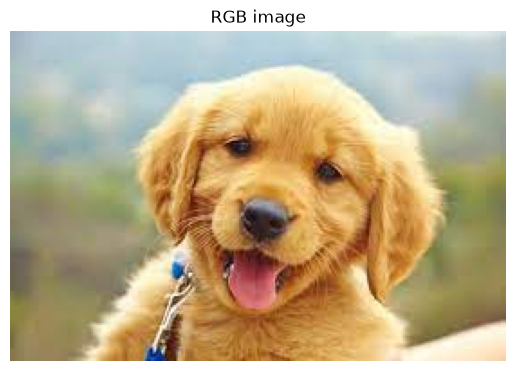

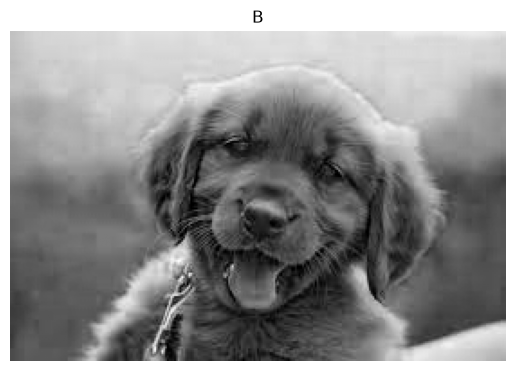

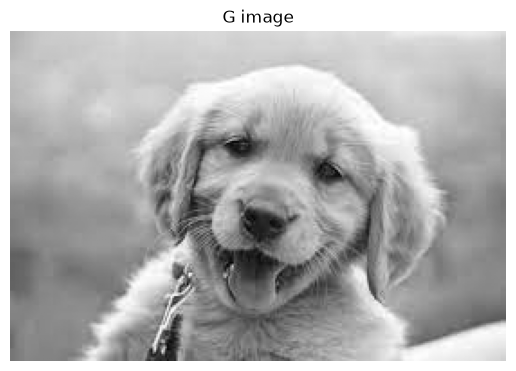

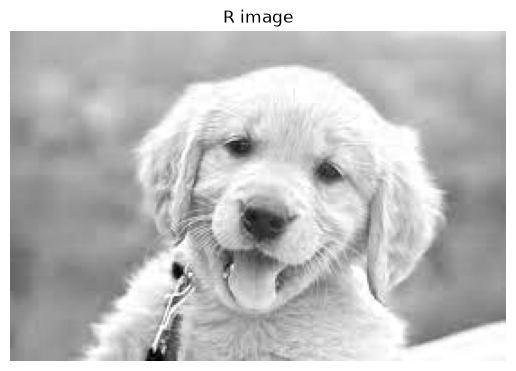

In [25]:
image = cv.imread("./images/dogBGR.jpg")
show(image, "RGB image")
# cv.split()
B,G ,R = cv.split(image)

show(B, "B")
show(G, "G image")
show(R, "R image")

### To change Color Spaces [cvtColor()](https://docs.opencv.org/3.4/d8/d01/group__imgproc__color__conversions.html)
1. The RGB Color Space and Gray Color Space
2. The LAB Color-Space
3. The YCrCb Color-Space

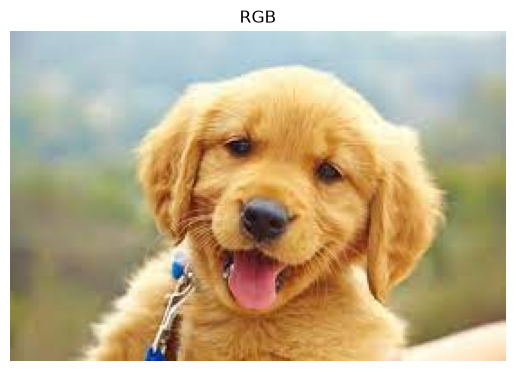

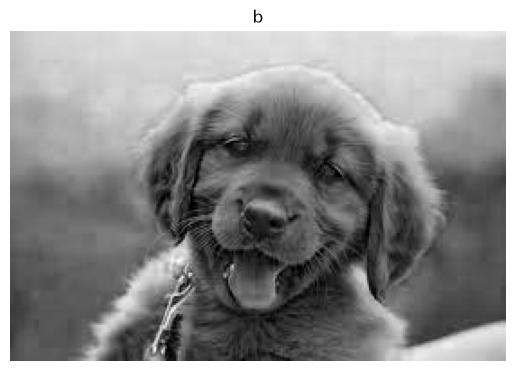

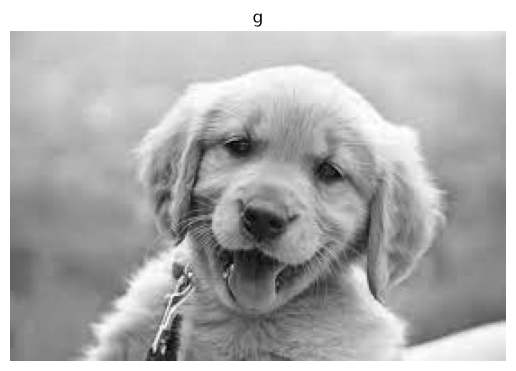

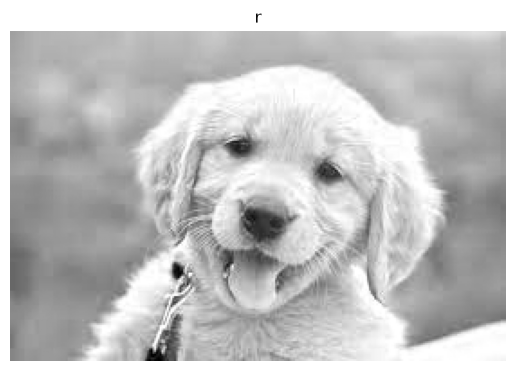

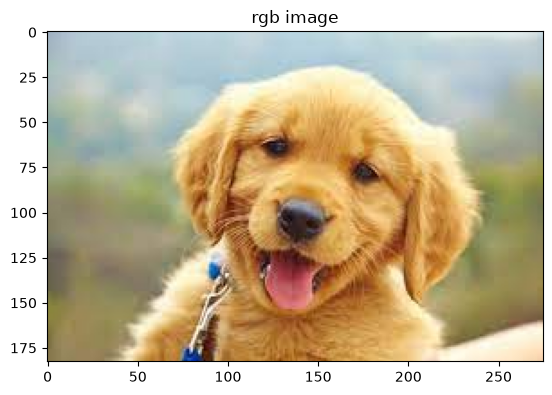

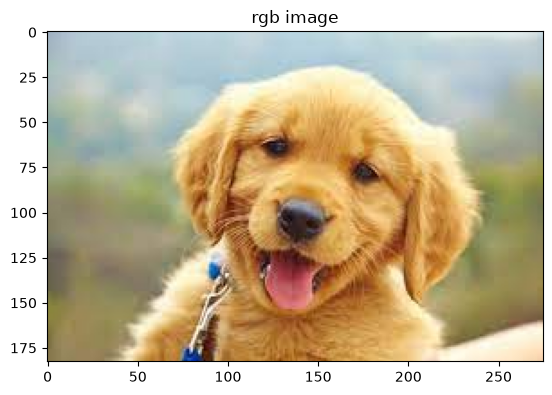

In [26]:
image = cv.imread('./images/dogBGR.jpg')
show(image, "RGB")
# split image into three channels 
B , G , R = cv.split(image)

show(B, "b")
show(G, "g")
show(R, "r")
# plt 
#cv.convertColor
rgb_image = cv.cvtColor(image , cv.COLOR_BGR2RGB)
rgbrev = image [:, : , ::-1]
plt.imshow(rgb_image)
plt.title('rgb image')
plt.show()



plt.imshow(rgbrev)
plt.title('rgb image')
plt.show()

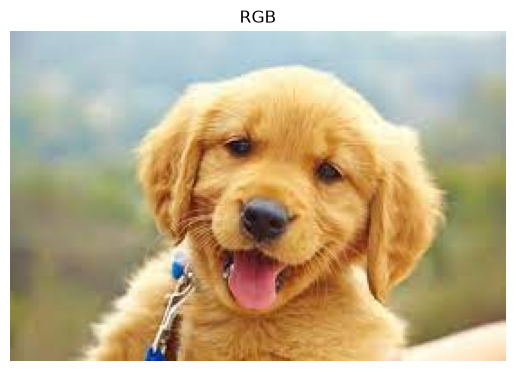

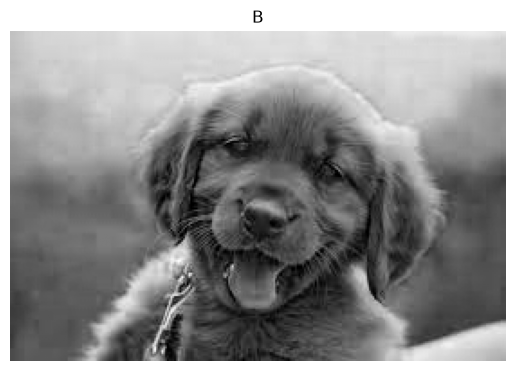

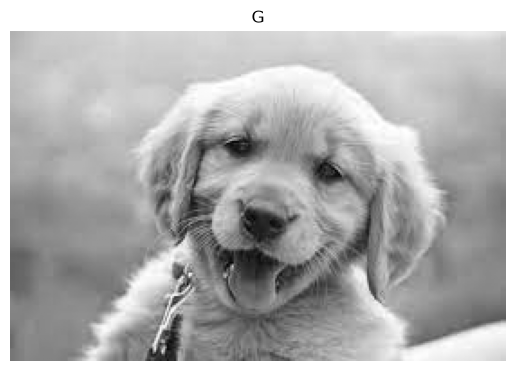

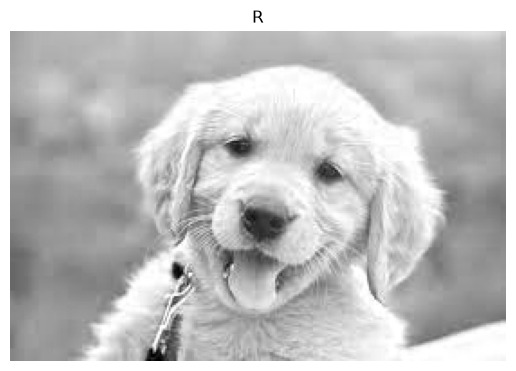

In [27]:
# load the original image and show it
image = cv.imread('./images/dogBGR.jpg')
show(image, "RGB")
# loop over each of the individual channels and display them
for (name, chan) in zip(("B", "G", "R"), cv.split(image)):
	show(chan, name)

## Change from BGR to RGB for solve matpoltlib problem
### To change Color Spaces [cvtColor()](https://docs.opencv.org/3.4/d8/d01/group__imgproc__color__conversions.html)
1. The RGB Color Space

In [28]:
matimage = cv.cvtColor(image , cv.COLOR_BGR2RGB)

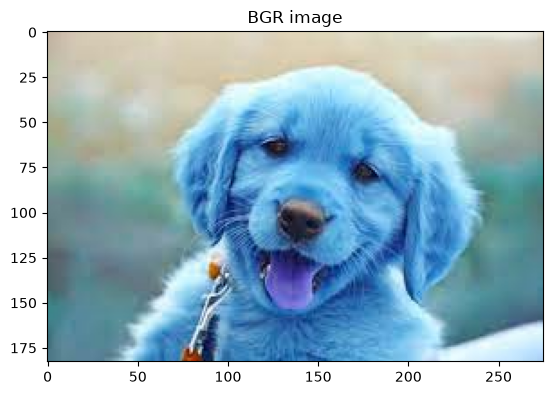

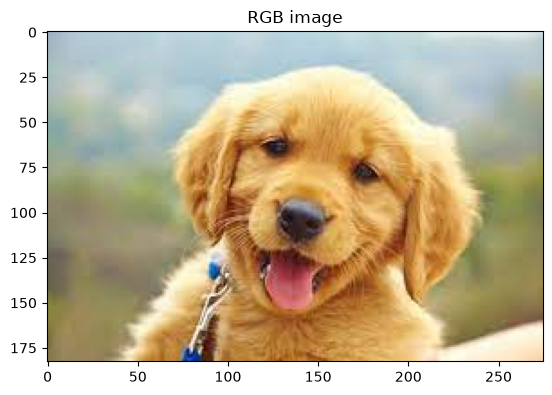

In [29]:
plt.imshow(image)
plt.title("BGR image")
plt.show()

plt.imshow(matimage)
plt.title("RGB image")
plt.show()

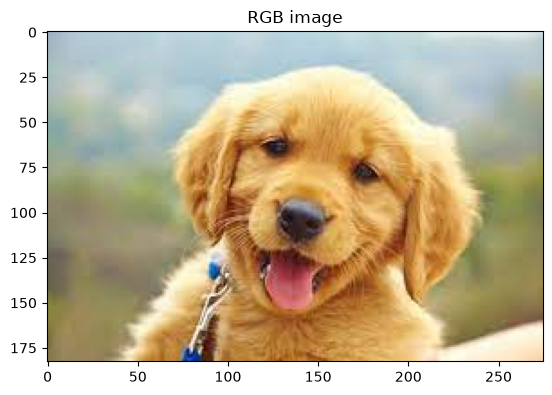

In [30]:
reverseimage = image[:,:,::-1]
plt.imshow(reverseimage)
plt.title("RGB image")
plt.show()

---
## Gray Color Space

In [31]:
grayimage = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

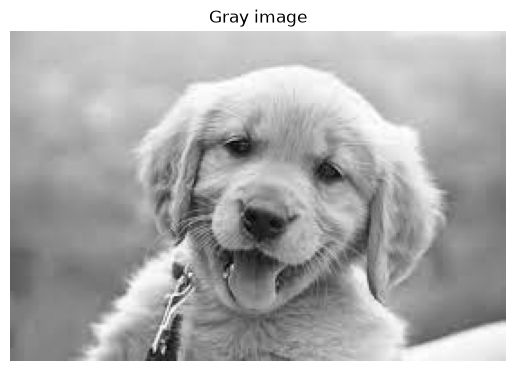

In [32]:
show(grayimage, "Gray image")

---
## The LAB Color-Space

The Lab color space has three components.

1. L – Lightness ( Intensity ).
2. a – color component ranging from Green to Magenta.
3. b – color component ranging from Blue to Yellow.

In [33]:
LAB_img = cv.cvtColor(image,cv.COLOR_BGR2LAB)

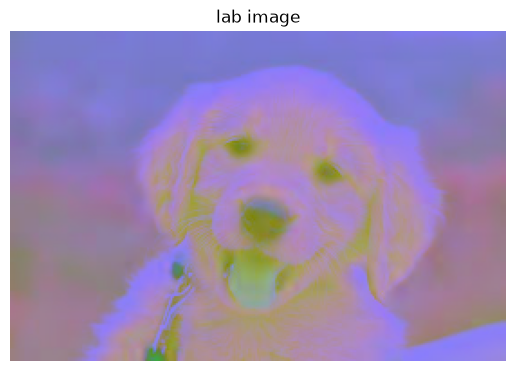

In [34]:
show(LAB_img, "lab image")

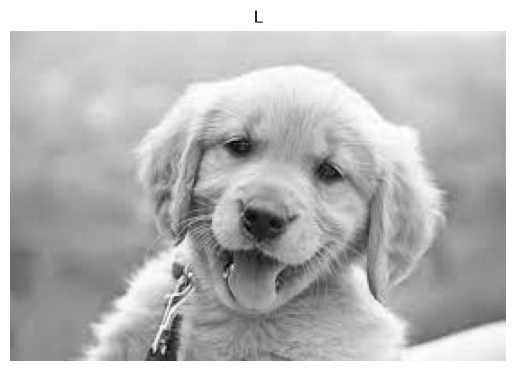

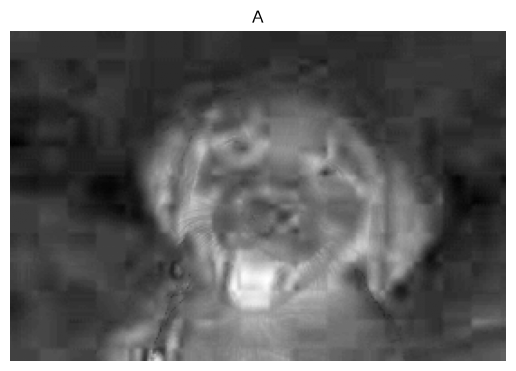

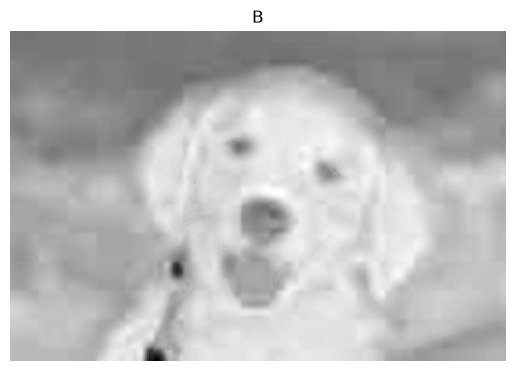

In [35]:
# split image into three channels 
L , A , B = cv.split(LAB_img)

show(L, "L")
show(A, "A")
show(B, "B")

---
## The YCrCb Color-Space 


### The YCrCb color space is derived from the RGB color space and has the following three compoenents.

1. Y – Luminance or Luma component obtained from RGB after gamma correction.
2. Cr = R – Y ( how far is the red component from Luma ).
3. Cb = B – Y ( how far is the blue component from Luma ).

In [36]:
YCrCb_img = cv.cvtColor(image,cv.COLOR_BGR2YCrCb)

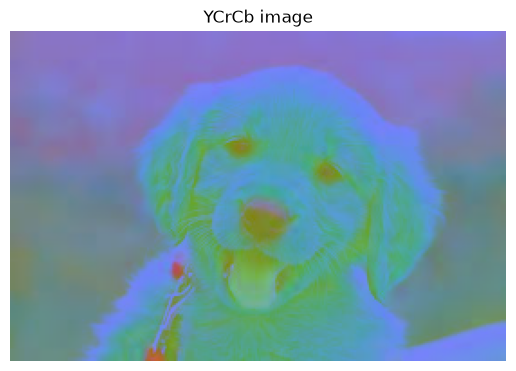

In [37]:
show(YCrCb_img, "YCrCb image")

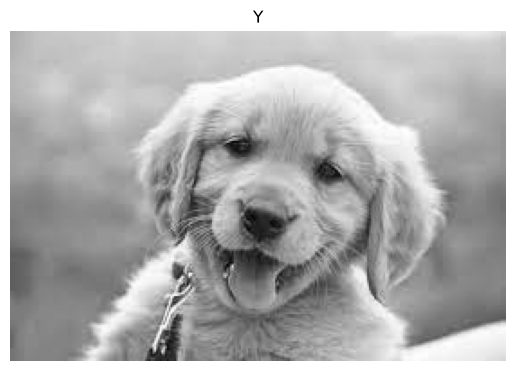

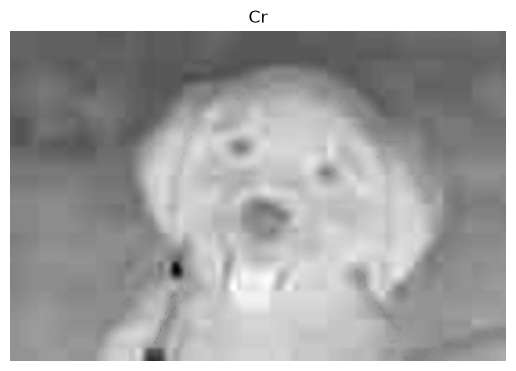

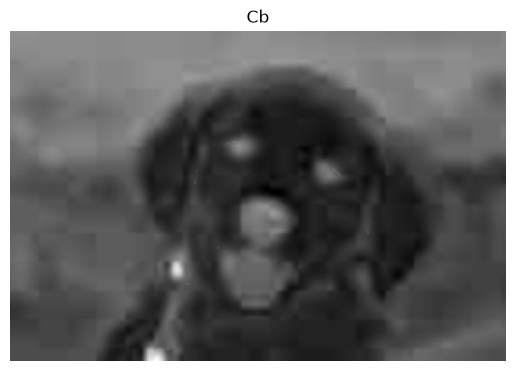

In [38]:
# split image into three channels 
Y , Cr , Cb = cv.split(YCrCb_img)

show(Y, "Y")
show(Cr, "Cr")
show(Cb, "Cb")

---
## The HSV Color Space

### The HSV color space has the following three components

- H – Hue ( Dominant Wavelength ).
- S – Saturation ( Purity / shades of the color ).
- V – Value ( Intensity ).

In [39]:
HSV_img = cv.cvtColor(image,cv.COLOR_BGR2HSV)

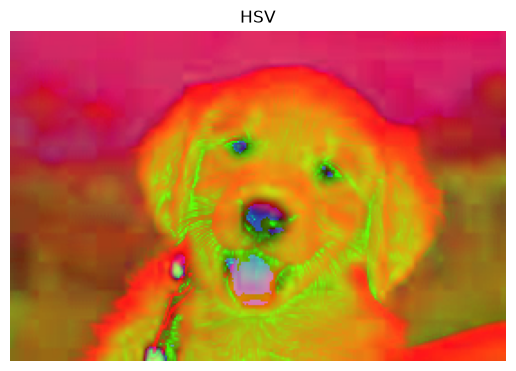

In [40]:
show(HSV_img, "HSV")

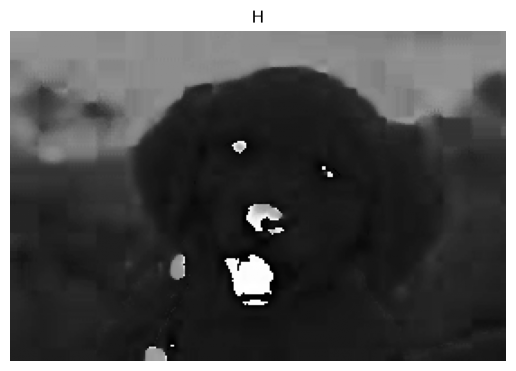

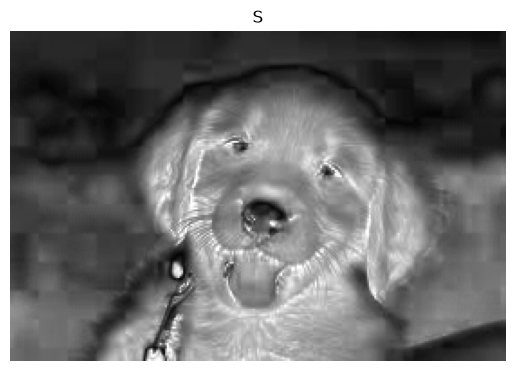

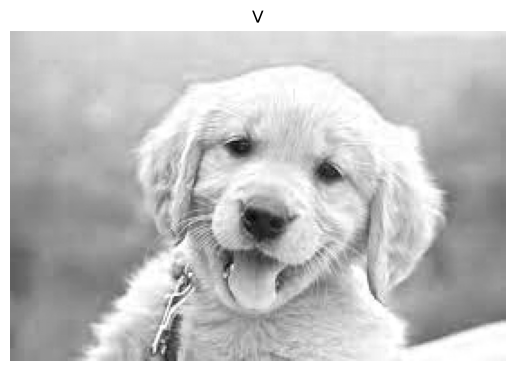

In [41]:
# split image into three channels 
H , S , V = cv.split(HSV_img)

show(H, "H")
show(S, "S")
show(V, "V")

In [42]:
# Helper function to show

def pair_plot(img1, img2, title1="Original", title2="Filtered"):
    fig = plt.figure(figsize=(16, 16))
    fig.add_subplot(1,2,1)
    plt.imshow(img1)
    plt.title(title1)
    plt.axis("off")
    fig.add_subplot(1,2,2)
    plt.imshow(img2)
    plt.title(title2)
    plt.axis("off")

---
# Image enhancement and filtering techniques.


## Spatial Filtering
To perform spatial filtering we need a mask that highlights the neighborhood of a pixel. The combination of mask and function is called a filter. As illustrated in the following figure, to calculate the value of the output pixel, we multiply all elements in the mask by elements in the neighborhood, and add up all these products.

<img src="images/spatial.png" width=600 height=600/>
---

## Low-Pass Filters (Smoothing Filters)

* Linear Filters
    - Mean (Avg) Filter
* Non-linear Filters
    - Gaussian Filter
    - Median Filter

## High-Pass Filters

- Laplacian Filter
- Sharpening Filter

In [43]:
img = cv.imread("images/hawk.png")

### Mean filter 

In [44]:
AvgKernel = np.array(
[[1,1 ,1],
[1,1 ,1],
[1,1 ,1],

])/9

In [45]:
AvgKernel


array([[0.11111111, 0.11111111, 0.11111111],
       [0.11111111, 0.11111111, 0.11111111],
       [0.11111111, 0.11111111, 0.11111111]])

In [46]:
avg_image = cv.filter2D(img,ddepth = -1 ,kernel = AvgKernel )# ddepth = -1 , kernel = kernel

In [47]:
kernel = np.array([ [1, 1 , 1],
                    [1 , 1 , 1],
                    [1, 1, 1],
])/9

In [48]:
kernel

array([[0.11111111, 0.11111111, 0.11111111],
       [0.11111111, 0.11111111, 0.11111111],
       [0.11111111, 0.11111111, 0.11111111]])

In [49]:
# Same as np.ones((n, m)) / (n*m)
kernel = np.ones((3, 3)) / 9
kernel

array([[0.11111111, 0.11111111, 0.11111111],
       [0.11111111, 0.11111111, 0.11111111],
       [0.11111111, 0.11111111, 0.11111111]])

---
## To apply any kernel 
`cv.filter2D (src, ddepth, kernel)`

Use to apply any 2D filter to an image

`src`: Input Image<br>
`ddepth`: depth of the resulting image. Default = -1 (same depth as source image)<br>
`kernel`: The filter to be applied<br

In [50]:
avg_image = cv.filter2D(img , ddepth = -1 , kernel = kernel)

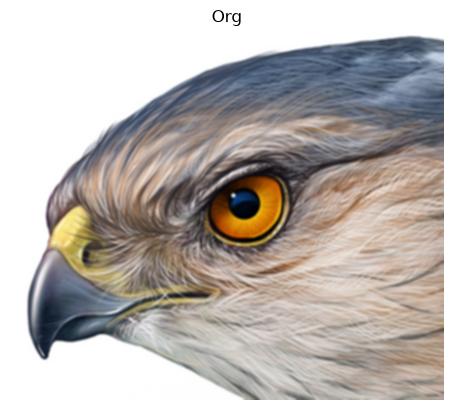

In [51]:
show(avg_image, "Org")

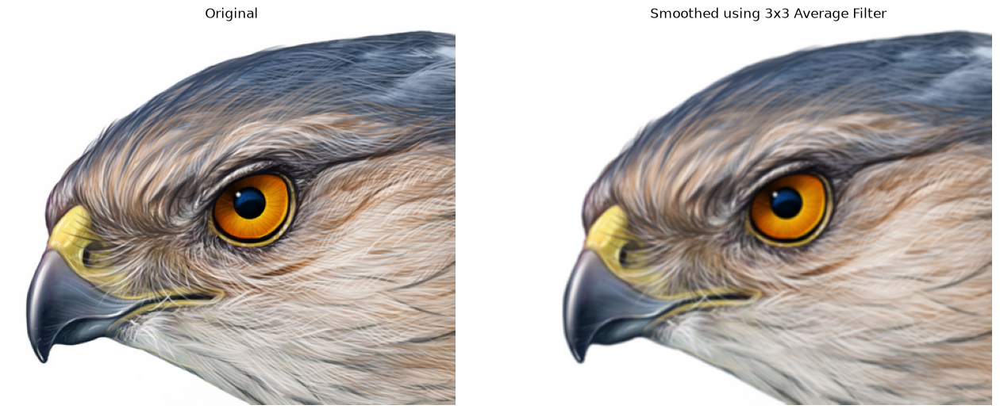

In [52]:
pair_plot(img[: , : , ::-1], avg_image[:,:,::-1], title1="Original", title2="Smoothed using 3x3 Average Filter")

In [53]:
blurimag = cv.blur(image ,ksize = (3,3))

Similar Functions:

`cv.blur(src, ksize[, dst[, anchor[, borderType]]]) -> dst`: <br>
- `src` input image; it can have any number of channels, which are processed independently, but the depth should be CV_8U, CV_16U, CV_16S, CV_32F or CV_64F.
- `dst` output image of the same size and type as src.
- `ksize` blurring kernel size.
- `anchor` anchor point; default value Point(-1,-1) means that the anchor is at the kernel center.
- `borderType` border mode used to extrapolate pixels outside of the image. See https://docs.opencv.org/3.4/d2/de8/group__core__array.html#ga209f2f4869e304c82d07739337eae7c5

Same as: `cv.boxFilter(src, dst, src.type(), ksize, anchor, true, borderType)`

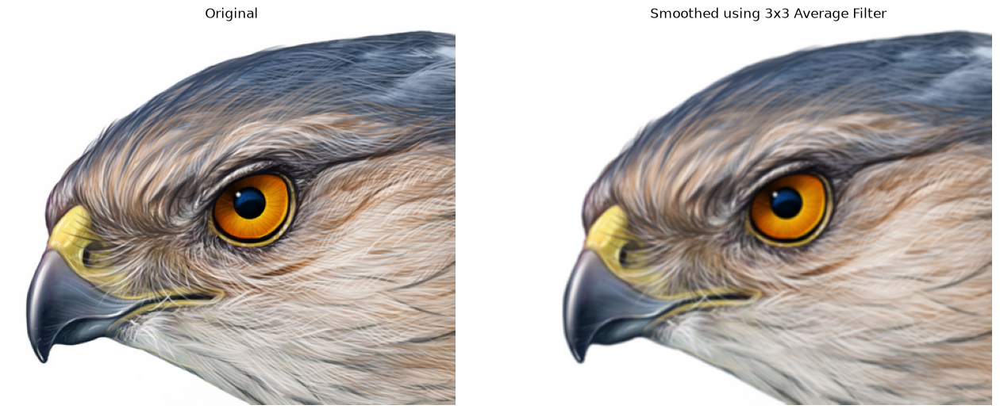

In [54]:
out = cv.blur(img, (3, 3))
pair_plot(img[:,:,::-1], out[: , : , ::-1], title1="Original", title2="Smoothed using 3x3 Average Filter")

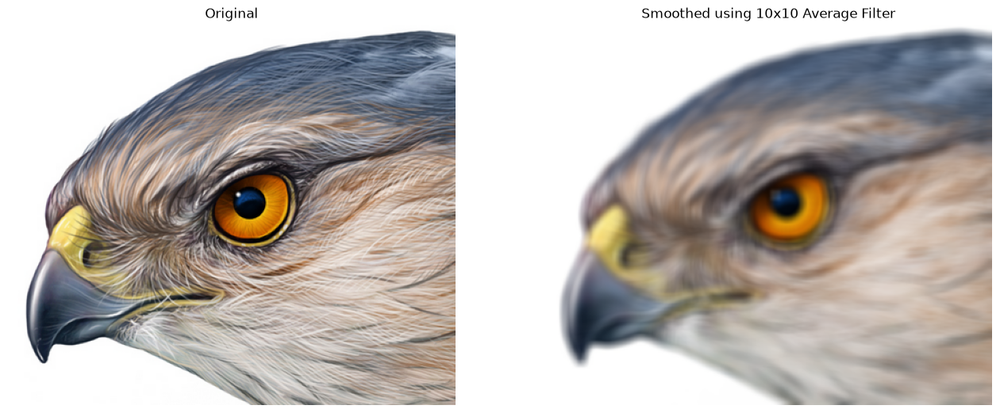

In [55]:
out = cv.blur(img, (10, 10))
pair_plot(img[:,:,::-1], out[: , : , ::-1], title1="Original", title2="Smoothed using 10x10 Average Filter")

--- 
### Gaussian Filter

GaussianBlur(src, ksize, sigmaX[, dst[, sigmaY[, borderType]]]) -> dst
- Blurs an image using a Gaussian filter.
- `src` input image; the image can have any number of channels, which are processed independently, but the depth should be CV_8U, CV_16U, CV_16S, CV_32F or CV_64F.
- `dst` output image of the same size and type as src.
- `ksize` Gaussian kernel size. ksize.width and ksize.height can differ but they both must be positive and odd. Or, they can be zero's and then they are computed from sigma.
- `sigmaX` Gaussian kernel standard deviation in X direction.
- `sigmaY` Gaussian kernel standard deviation in Y direction; if sigmaY is zero, it is set to be equal to sigmaX, if both sigmas are zeros, they are computed from ksize.width and ksize.height, respectively (see #getGaussianKernel for details); to fully control the result regardless of possible future modifications of all this semantics, it is recommended to specify all of ksize, sigmaX, and sigmaY.
- `borderType` pixel extrapolation method, see #BorderTypes. #BORDER_WRAP is not supported.

sigma calculation: *sigma = 0.3*((ksize-1)*0.5 - 1) + 0.8*

<img src="images/surf.png"/>

(<Figure size 640x480 with 1 Axes>,
 Text(0.5, 1.0, 'Sigma = 5'))

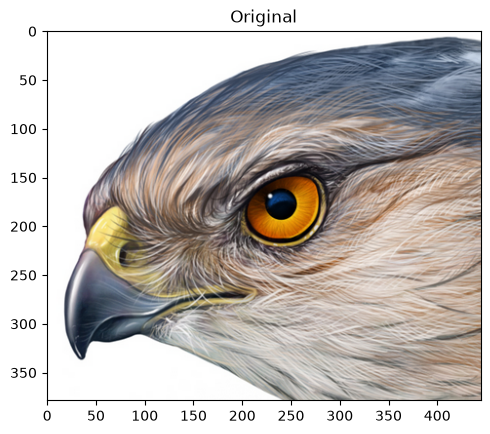

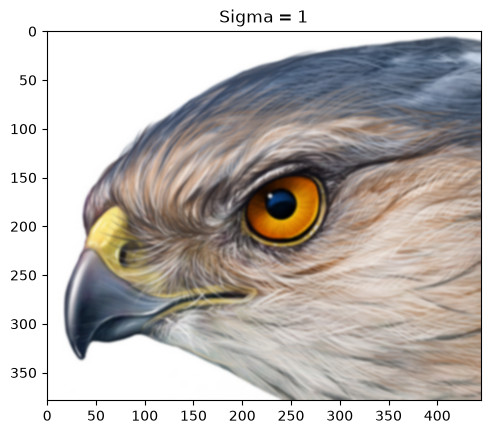

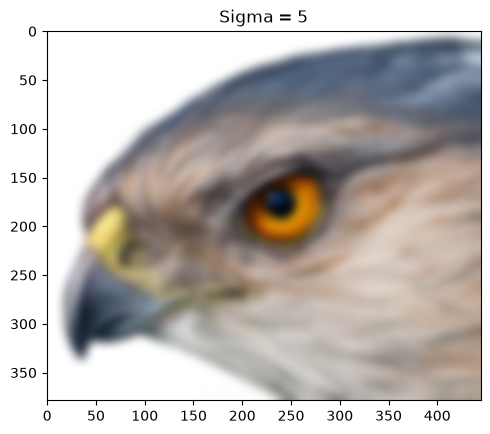

In [56]:
img = cv.imread("images/hawk.png")
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

plt.figure(), plt.imshow(img), plt.title('Original')

# Create and Apply a 5*5 Filter, sigma=5
out = cv.GaussianBlur(img, ksize=(5,5), sigmaX=1)
plt.figure(), plt.imshow(out), plt.title('Sigma = 1')

# Create and Apply a 21*21 Filter (2*ceil(2*sigma)+1), sigma=5
out = cv.GaussianBlur(img, ksize=(21,21), sigmaX=5)
plt.figure(), plt.imshow(out), plt.title('Sigma = 5')

--- 
### Median Filter

medianBlur(src, ksize[, dst]) -> dst
- Blurs an image using the median filter.

- `src` input 1-, 3-, or 4-channel image; when ksize is 3 or 5, the image depth should be CV_8U, CV_16U, or CV_32F, for larger aperture sizes, it can only be CV_8U.
- `dst` destination array of the same size and type as src.
- `ksize` aperture linear size; it must be odd and greater than 1, for example: 3, 5, 7 ...

*Note: The median filter uses #BORDER_REPLICATE internally to cope with border pixels, see #BorderTypes*

In [57]:
img = cv.imread('images/salt.jpeg')

(<Figure size 640x480 with 1 Axes>,
 Text(0.5, 1.0, 'Mean Filter'))

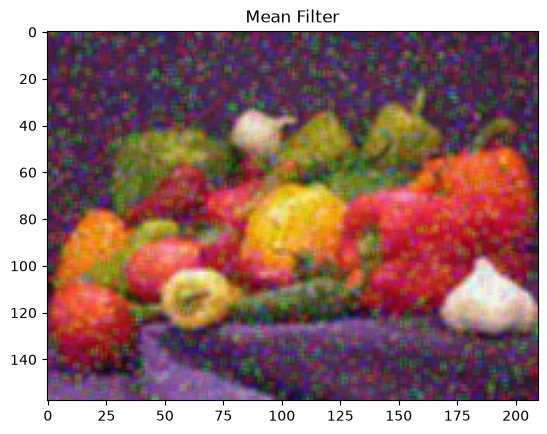

In [58]:
# Creates and Applies a 5*5 Mean Filter on the noisy img to remove the noise
outAvg = cv.blur(img, (3,3))
plt.figure(), plt.imshow(outAvg[: , : ,::-1], cmap="gray", vmin=0, vmax=255), plt.title('Mean Filter')

(<Figure size 640x480 with 1 Axes>,
 Text(0.5, 1.0, 'Gaussian Filter'))

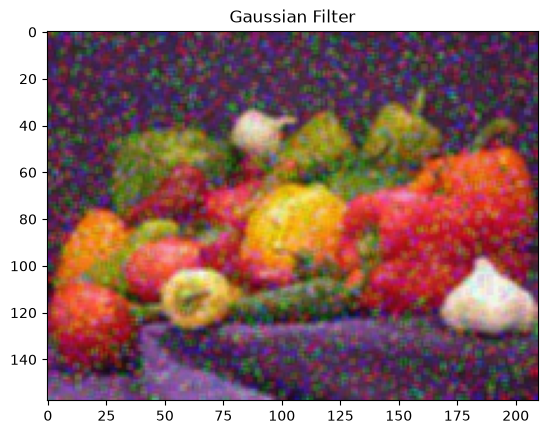

In [59]:
# Create and Apply a 25*25 Gaussian Filter to remove the noise
outGauss = cv.GaussianBlur(img, ksize=(3, 3), sigmaX=3)
plt.figure(), plt.imshow(outGauss[:, : , ::-1], cmap="gray", vmin=0, vmax=255), plt.title('Gaussian Filter')

(<Figure size 640x480 with 1 Axes>,
 Text(0.5, 1.0, 'Median Filter'))

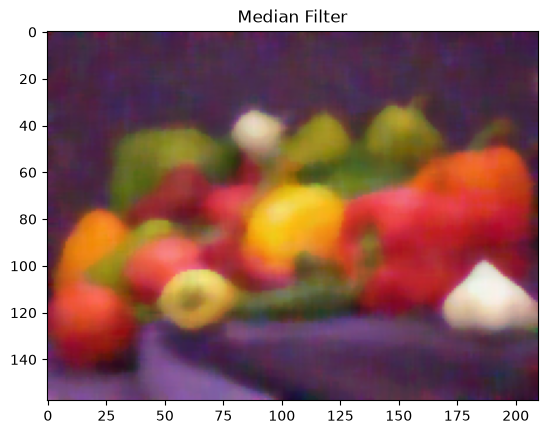

In [60]:
# Apply a Median Filter to remove the noise
outMed = cv.medianBlur(img,9)
plt.figure(), plt.imshow(outMed[: , : , ::-1], cmap="gray", vmin=0, vmax=255), plt.title('Median Filter')

(<Figure size 640x480 with 1 Axes>,
 Text(0.5, 1.0, 'Median Filter'))

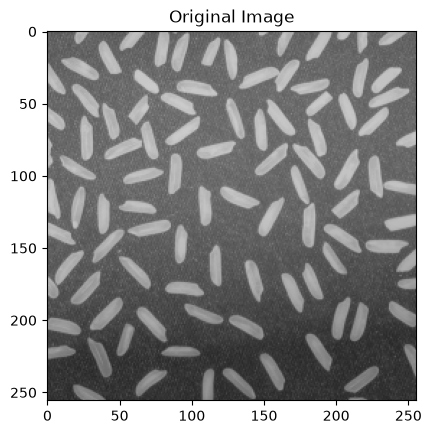

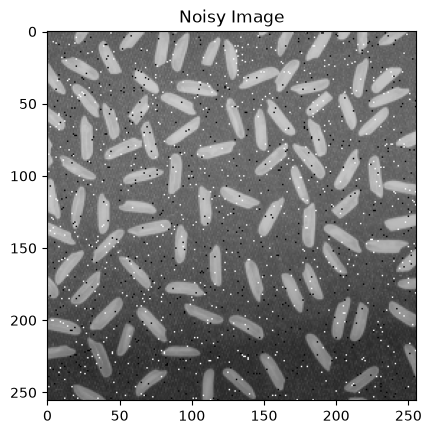

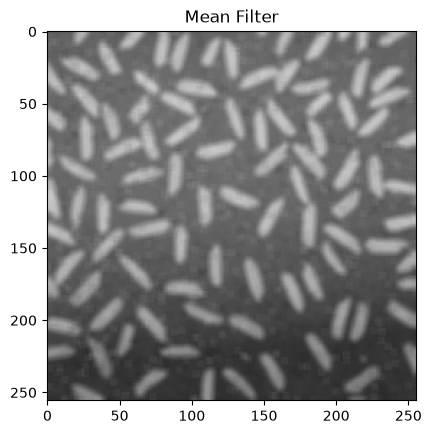

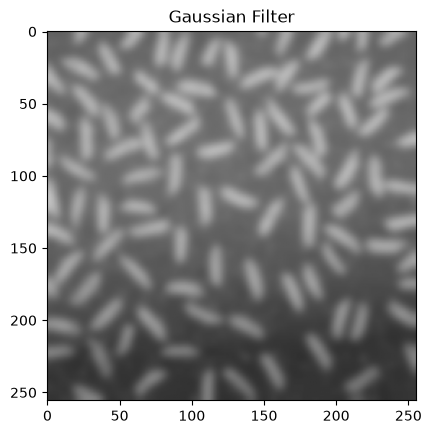

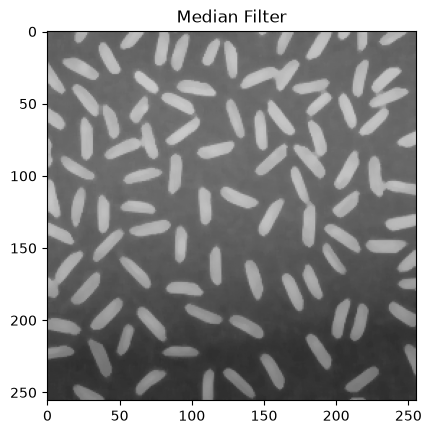

In [61]:
img = cv.imread('images/rice.png', cv.IMREAD_GRAYSCALE)
plt.figure(), plt.imshow(img, cmap="gray", vmin=0, vmax=255), plt.title('Original Image')

# Add *'salt and pepper'* noise to the image with density of 0.02
from skimage.util import random_noise
noisyImg = random_noise(img, mode="s&p",amount=0.02)
noisyImg = np.array(255*noisyImg, dtype="uint8")
plt.figure(), plt.imshow(noisyImg, cmap="gray", vmin=0, vmax=255), plt.title('Noisy Image')

# Creates and Applies a 5*5 Mean Filter on the noisy img to remove the noise
outAvg = cv.blur(noisyImg, (5,5))
plt.figure(), plt.imshow(outAvg, cmap="gray", vmin=0, vmax=255), plt.title('Mean Filter')

# Create and Apply a 25*25 Gaussian Filter to remove the noise
outGauss = cv.GaussianBlur(noisyImg, ksize=(25, 25), sigmaX=3)
plt.figure(), plt.imshow(outGauss, cmap="gray", vmin=0, vmax=255), plt.title('Gaussian Filter')

# Apply a Median Filter to remove the noise
outMed = cv.medianBlur(noisyImg, 5)
plt.figure(), plt.imshow(outMed, cmap="gray", vmin=0, vmax=255), plt.title('Median Filter')

--- 
## High-Pass Filters

- Laplacian Filter
- Sharpening Filter

In [62]:
laplacian_filt = np.array([[0, 1, 0], 
                           [1, -4, 1],
                           [0, 1, 0]])
laplacian_filt

array([[ 0,  1,  0],
       [ 1, -4,  1],
       [ 0,  1,  0]])

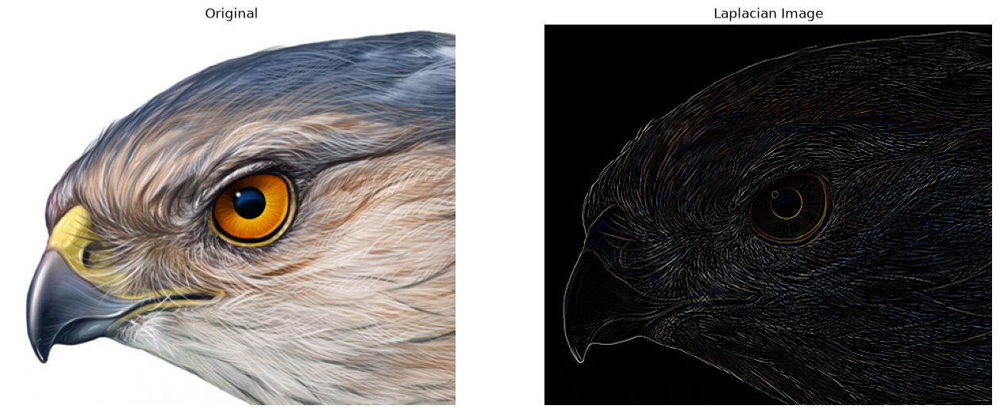

In [63]:
img = cv.imread("images/hawk.png")
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
out = cv.filter2D(img, -1, laplacian_filt)
pair_plot(img, out, 'Original', 'Laplacian Image')

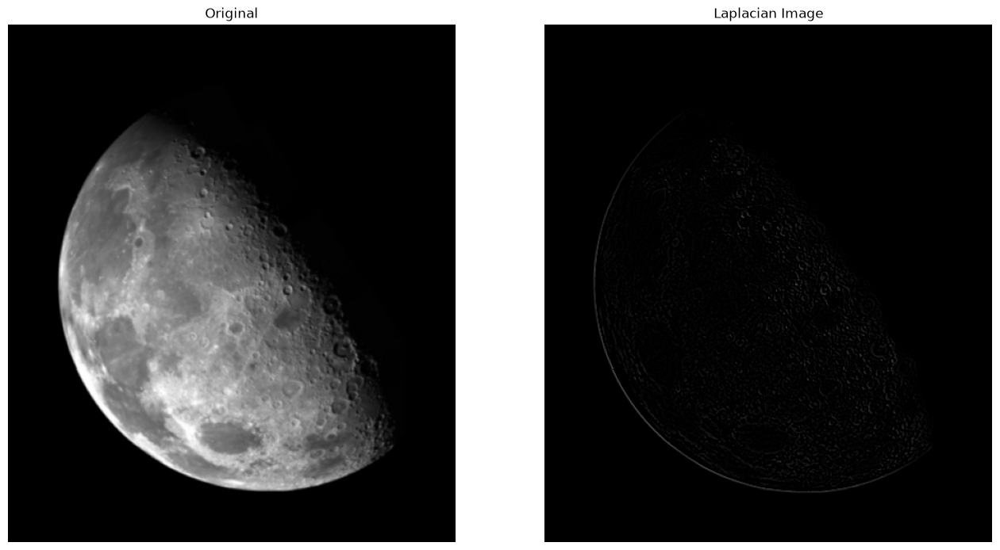

In [64]:
img = cv.imread("images/moon.jpg")
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
out = cv.filter2D(img, -1, laplacian_filt)
pair_plot(img, out, 'Original', 'Laplacian Image')

In [65]:
sharpen_filter = np.array([[0,-1, 0], 
                          [-1, 5,-1],
                          [0,-1, 0]])

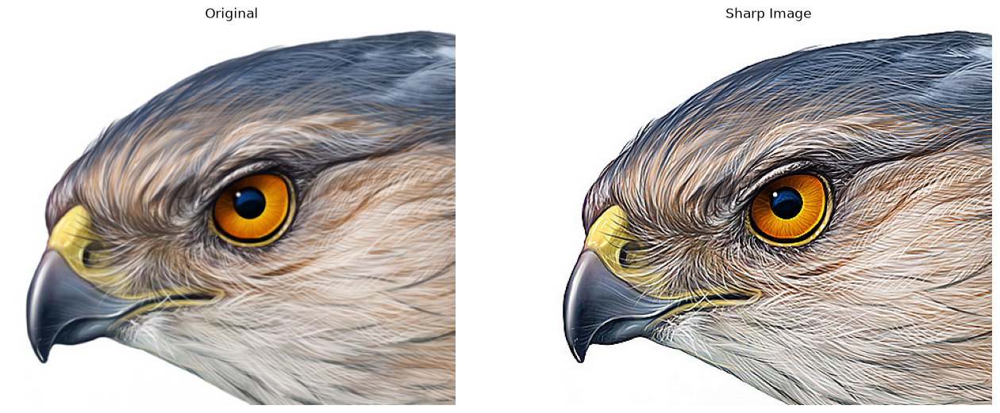

In [66]:
img = cv.imread("images/hawk.png")
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
sharpImg = cv.filter2D(img, -1, sharpen_filter)
pair_plot(img, sharpImg, 'Original', 'Sharp Image')

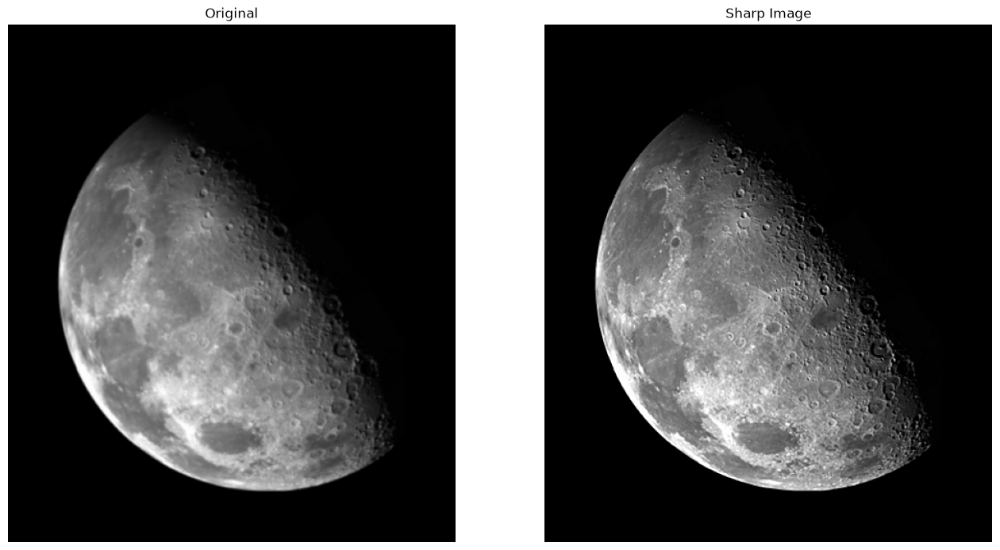

In [67]:
img = cv.imread("images/moon.jpg")
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
sharpImg = cv.filter2D(img, -1, sharpen_filter)
pair_plot(img, sharpImg, 'Original', 'Sharp Image')

## Exersices

### for camera
1. get feed of your camera and change color space to gray 
2. when get each frame from camera sharpe frame 
3. add noise salt and paper in frame 
4. remove salt and paper noises from frame 

### for Video 

1. get feed of your camera and change color space to gray 
2. when get each frame from camera sharpe frame 
3. add noise salt and paper in frame 
4. remove salt and paper noises from frame 


### image enhancment Next Session 

<img src="../assets/reference_images/stock_photo_placeholder.jpg" alt="drawing" style="width:500px;"/>